In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

df = pd.read_csv('../artifacts/outputs/predictions.csv')

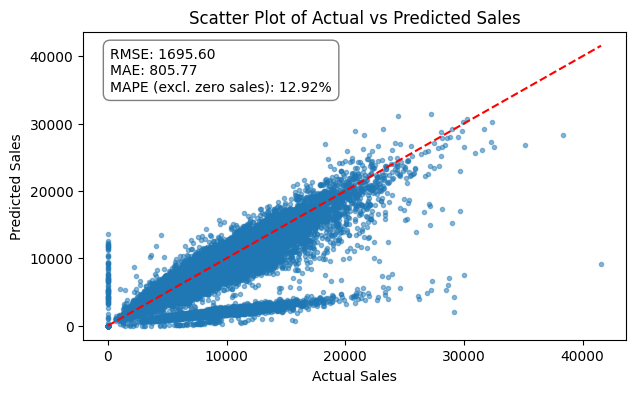

In [15]:
rmse = root_mean_squared_error(df['Sales_actual'], df['Sales_predicted'])
mae = mean_absolute_error(df['Sales_actual'], df['Sales_predicted'])

# sales might be zero, so we need to handle that case to avoid division by zero
df_nonzero = df[df['Sales_actual'] != 0]
mape = mean_absolute_percentage_error(df_nonzero['Sales_actual'], df_nonzero['Sales_predicted']) * 100


plt.figure(figsize=(7, 4))
plt.scatter(df['Sales_actual'], df['Sales_predicted'], marker='.', alpha=0.5)
plt.plot([df['Sales_actual'].min(), df['Sales_actual'].max()],
         [df['Sales_actual'].min(), df['Sales_actual'].max()],
         color='red', linestyle='--')

plt.annotate(f'RMSE: {rmse:.2f}\nMAE: {mae:.2f}\nMAPE (excl. zero sales): {mape:.2f}%',
             xy=(0.05, 0.95), 
             xycoords='axes fraction',
             horizontalalignment='left',
             verticalalignment='top',
             bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.5))

plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Scatter Plot of Actual vs Predicted Sales')
plt.show()

In [17]:

rmse = root_mean_squared_error(df['Sales_actual'], df['Sales_predicted'])
mae = mean_absolute_error(df['Sales_actual'], df['Sales_predicted'])
df_nonzero = df[df['Sales_actual'] != 0]
mape = mean_absolute_percentage_error(df_nonzero['Sales_actual'], df_nonzero['Sales_predicted']) * 100

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(df['Sales_actual'], df['Sales_predicted'], marker='.', alpha=0.5)
ax.plot([df['Sales_actual'].min(), df['Sales_actual'].max()],
        [df['Sales_actual'].min(), df['Sales_actual'].max()],
        color='red', linestyle='--')
ax.annotate(f'RMSE: {rmse:.2f}\nMAE: {mae:.2f}\nMAPE (excl. zero sales): {mape:.2f}%',
            xy=(0.05, 0.95), xycoords='axes fraction',
            horizontalalignment='left', verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.5))
ax.set_xlabel('Actual Sales')
ax.set_ylabel('Predicted Sales')
ax.set_title('Actual vs Predicted Sales')
fig.tight_layout()
fig.savefig('../assets/actual_vs_predicted.png', dpi=150)
plt.close(fig)
print("Saved to ../assets/actual_vs_predicted.png")


Saved to ../assets/actual_vs_predicted.png


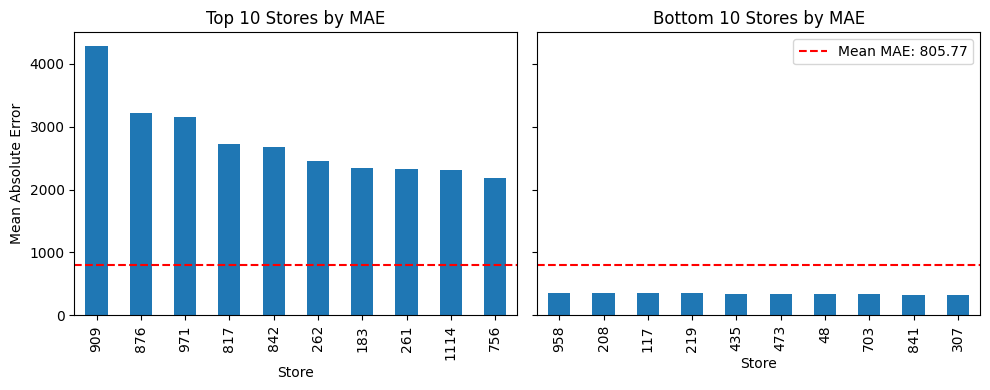

In [16]:
errors_per_store = (df
                    .groupby('Store')
                    .apply(lambda x: mean_absolute_error(x['Sales_actual'], x['Sales_predicted']), include_groups=False)
                    .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 4), ncols=2, sharey=True)

errors_per_store.head(10).plot(kind='bar', ax=ax[0])
errors_per_store.tail(10).plot(kind='bar', ax=ax[1])
ax[0].set_title('Top 10 Stores by MAE')
ax[1].set_title('Bottom 10 Stores by MAE')
ax[0].set_ylabel('Mean Absolute Error')

# add a horizontal line at the mean MAE across all stores
mean_mae = errors_per_store.mean()
ax[0].axhline(mean_mae, color='red', linestyle='--', label=f'Mean MAE: {mean_mae:.2f}')
ax[1].axhline(mean_mae, color='red', linestyle='--', label=f'Mean MAE: {mean_mae:.2f}')
plt.legend()
plt.tight_layout()

Saved to ../assets/mae_per_store.png


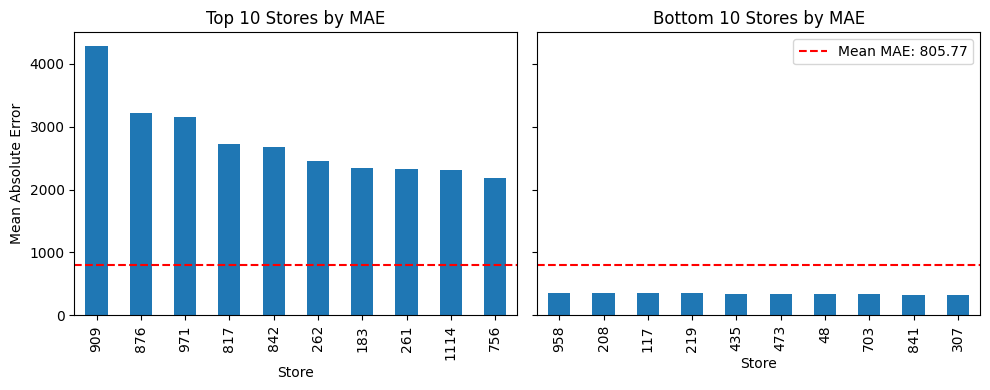

In [20]:

fig2, ax2 = plt.subplots(figsize=(10, 4), ncols=2, sharey=True)
errors_per_store.head(10).plot(kind='bar', ax=ax2[0])
errors_per_store.tail(10).plot(kind='bar', ax=ax2[1])
ax2[0].set_title('Top 10 Stores by MAE')
ax2[1].set_title('Bottom 10 Stores by MAE')
ax2[0].set_ylabel('Mean Absolute Error')
mean_mae = errors_per_store.mean()
ax2[0].axhline(mean_mae, color='red', linestyle='--', label=f'Mean MAE: {mean_mae:.2f}')
ax2[1].axhline(mean_mae, color='red', linestyle='--', label=f'Mean MAE: {mean_mae:.2f}')
ax2[1].legend()
fig2.tight_layout()
fig2.savefig('../assets/mae_per_store.png', dpi=150)
print("Saved to ../assets/mae_per_store.png")


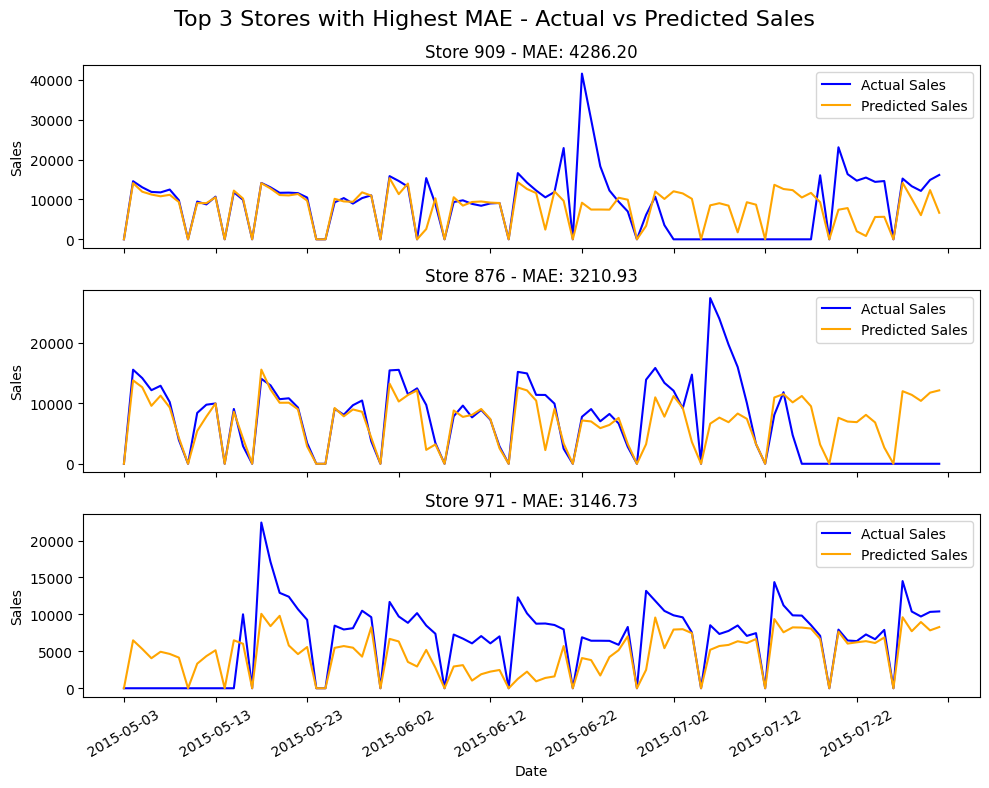

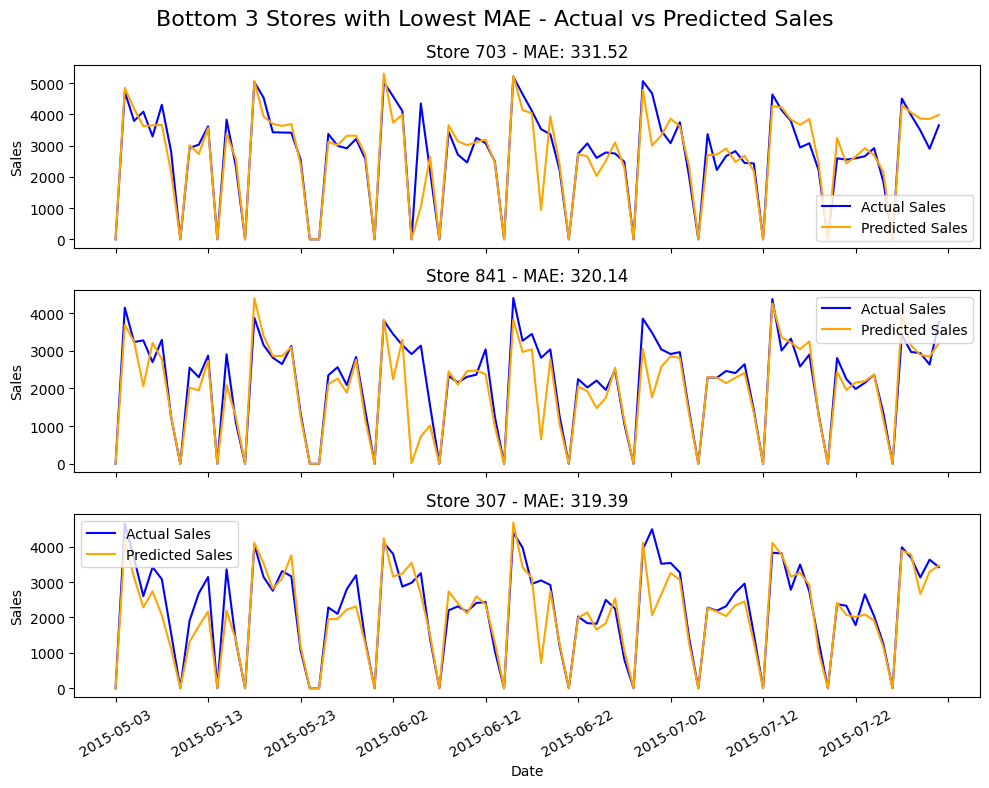

In [11]:
# plot timeseries for the top 3 stores with the highest MAE on 3 sibgraphs
top_3_stores = errors_per_store.head(3).index.tolist()
bottom_3_stores = errors_per_store.tail(3).index.tolist()

for stores in [top_3_stores, bottom_3_stores]:
    fig, ax = plt.subplots(figsize=(10, 8), nrows=3, sharex=True)
    for i, store in enumerate(stores):
        store_data = df[df['Store'] == store]
        ax[i].plot(store_data['Date'], store_data['Sales_actual'], label='Actual Sales', color='blue')
        ax[i].plot(store_data['Date'], store_data['Sales_predicted'], label='Predicted Sales', color='orange')
        ax[i].set_title(f'Store {store} - MAE: {errors_per_store[store]:.2f}')
        ax[i].set_ylabel('Sales')
        ax[i].legend()

        # make fewer ticks on the x-axis for better readability
        ax[i].xaxis.set_major_locator(plt.MaxNLocator(12))

    # Make the x-axis labels more readable
    if stores == top_3_stores:
        plt.suptitle('Top 3 Stores with Highest MAE - Actual vs Predicted Sales', fontsize=16)
    else:
        plt.suptitle('Bottom 3 Stores with Lowest MAE - Actual vs Predicted Sales', fontsize=16)
    plt.xticks(rotation=30)
    plt.xlabel('Date')
    plt.tight_layout()

In [19]:

fig3, ax3 = plt.subplots(figsize=(10, 8), nrows=3, sharex=True)
for i, store in enumerate(bottom_3_stores):
    store_data = df[df['Store'] == store]
    ax3[i].plot(store_data['Date'], store_data['Sales_actual'], label='Actual', color='blue')
    ax3[i].plot(store_data['Date'], store_data['Sales_predicted'], label='Predicted', color='orange')
    ax3[i].set_title(f'Store {store} – MAE: {errors_per_store[store]:.2f}')
    ax3[i].set_ylabel('Sales')
    ax3[i].legend()
    ax3[i].xaxis.set_major_locator(plt.MaxNLocator(12))
plt.suptitle('3 Stores with Lowest MAE – Actual vs Predicted Sales', fontsize=14)
plt.xticks(rotation=30)
plt.xlabel('Date')
fig3.tight_layout()
fig3.savefig('../assets/timeseries_lowest_mae.png', dpi=150)
plt.close(fig3)
print("Saved to ../assets/timeseries_lowest_mae.png")


Saved to ../assets/timeseries_lowest_mae.png


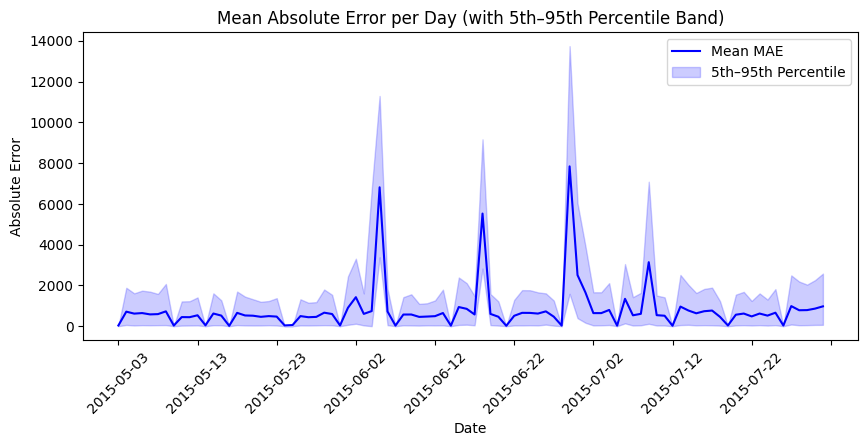

In [12]:
# Compute per-store absolute error for each day, then summarise with percentiles
abs_errors = df.copy()
abs_errors['abs_error'] = (abs_errors['Sales_actual'] - abs_errors['Sales_predicted']).abs()

errors_per_day = (abs_errors
                  .groupby('Date')['abs_error']
                  .agg(mean_mae='mean', p05=lambda x: np.percentile(x, 5), p95=lambda x: np.percentile(x, 95))
                  .sort_index())

# plot mean and 5th–95th percentile band per day
plt.figure(figsize=(10, 4))
plt.plot(errors_per_day.index, errors_per_day['mean_mae'], label='Mean MAE', color='blue')
plt.fill_between(errors_per_day.index,
                 errors_per_day['p05'],
                 errors_per_day['p95'],
                 color='blue', alpha=0.2, label='5th–95th Percentile')
plt.title('Mean Absolute Error per Day (with 5th–95th Percentile Band)')
plt.xlabel('Date')
plt.ylabel('Absolute Error')
plt.legend()

plt.gca().xaxis.set_major_locator(plt.MaxNLocator(12))
plt.xticks(rotation=45);


In [13]:
# Get top 10 dates with the highest mean absolute error
top_10_dates = errors_per_day.sort_values(by='mean_mae', ascending=False).head(10)
top_10_dates

,mean_mae,p05,p95
Date,,,
2015-06-29,7838.516592,1584.6,13734.5
2015-06-05,6811.964126,3379.0,11291.7
2015-06-18,5523.362332,2826.4,9163.5
2015-07-09,3138.528251,116.1,7086.1
2015-06-30,2505.301345,392.8,6021.9
2015-07-01,1654.333632,166.7,3923.5
2015-06-02,1421.860090,119.0,3310.0
2015-07-06,1341.295067,137.7,3045.7
2015-07-27,984.082511,80.7,2490.7
